# 3.2.2 MIND 多兴趣召回

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

当用户同时喜欢科幻、跑步和烹饪时，为什么一个平均向量会丢失兴趣？如何用多个向量分别检索？

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [Li et al., 2019, MIND](https://arxiv.org/abs/1904.08030)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 当用户同时喜欢科幻、跑步和烹饪时，为什么一个平均向量会丢失兴趣？如何用多个向量分别检索？

**先修知识：** 3.0 的向量、概率与损失函数。第一次阅读无需推导梯度，只要能解释输入、输出和形状。

## Paper & Context

MIND 用动态路由把行为序列聚成多个兴趣胶囊，训练时用 label-aware attention 选择与目标物品最相关的兴趣。关键变化是单用户单向量变成单用户多向量；代价是多路 ANN、去重和兴趣数选择。

**来源：** [Li et al., 2019, MIND](https://arxiv.org/abs/1904.08030)

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Math by Hand

设用户有 $K$ 个兴趣向量 $V_u=[v_1,\ldots,v_K]$。候选物品 $e_i$ 的分数取 $\max_k v_k^\top e_i$。可先把历史点分成两团，各自平均得到两个质心；若强行平均成一个点，它可能落在两团之间，反而不像任何真实兴趣。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

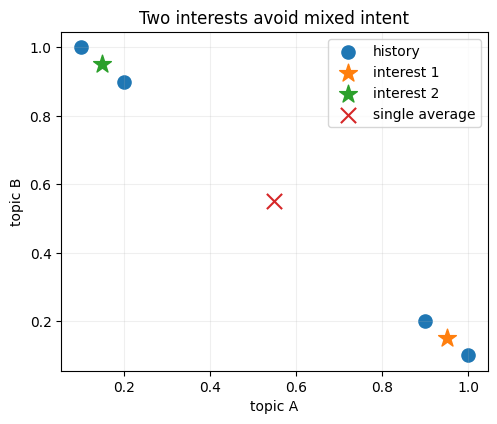

{'interest_1': [0.95, 0.15000000000000002], 'interest_2': [0.15000000000000002, 0.95], 'single': [0.55, 0.55]}


In [2]:
import numpy as np, matplotlib.pyplot as plt
history=np.array([[1,.1],[.9,.2],[.1,1],[.2,.9]])
a,b,single=history[:2].mean(0),history[2:].mean(0),history.mean(0)
fig,ax=plt.subplots(figsize=(5.5,4.4)); ax.scatter(history[:,0],history[:,1],s=90,label='history')
ax.scatter(*a,s=180,marker='*',label='interest 1'); ax.scatter(*b,s=180,marker='*',label='interest 2')
ax.scatter(*single,s=120,marker='x',label='single average'); ax.set(title='Two interests avoid mixed intent',xlabel='topic A',ylabel='topic B')
ax.legend(); ax.grid(alpha=.2); plt.show()
print({'interest_1':a.tolist(),'interest_2':b.tolist(),'single':single.tolist()})

## Data

MovieLens 真实评分按用户和时间排序；高评分电影组成兴趣历史与目标，用户真实低评分电影提供负样本。

**防泄漏清单：**按时间切分；词表只由训练期建立；负样本来自已观察低评分；序列只看预测时刻以前；测试集只在最后评价。CPU 档使用真实数据的确定性子集，**不是统一 benchmark 成绩**。

## Model & Framework

实际使用 torch_rechub.models.matching.MIND，执行 CapsuleNetwork、目标兴趣选择和多兴趣推理；full profile 映射 TorchEasyRec MIND。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from recsys_lab.industrial_experiments import run_mind, save_records

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_mind))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_mind(epochs: int = 26) -> dict:
    seed_everything(); ratings, _, provenance = _real_ratings()
    rows = _mind_rows(ratings); n_users, n_items = ratings.user_id.nunique(), ratings.item_id.nunique(); history_length = 10
    user_feature = [SparseFeature("user_id", n_users + 1, 12)]
    item_feature = [SparseFeature("item_id", n_items + 1, 12, padding_idx=0)]
    history_feature = [SequenceFeature("history", n_items + 1, 12, pooling="concat", shared_with="item_id", padding_idx=0)]
    negative_feature = [SequenceFeature("negative_items", n_items + 1, 12, pooling="concat", shared_with="item_id", padding_idx=0)]
    model = MIND(user_feature, history_feature, item_feature, negative_feature, history_length, interest_num=2)
    train_data = {
        "user_id": torch.tensor([r[0] for r in rows]),
        "history": torch.tensor([r[1] for r in rows]),
        "item_id": torch.tensor([r[2] for r in rows]),
        "negative_items": torch.tensor([r[3] for r in

## Train & Inference

下一格实际执行完整 smoke：固定 seed、构造数据、实例化模型、训练、切换到推理路径并计算测试指标。

In [4]:
result = run_mind()
print({'framework': result['framework'], 'dataset': result.get('dataset', {})})
print('inference contract:', 'user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

{'framework': 'torch_rechub.models.matching.MIND', 'dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 20241, 'users_used': 96, 'items_used': 480, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0, 'sequence_users': 96, 'history_length': 10, 'negative_source': 'observed rating <= 3.0'}}
inference contract: user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。
loss: 1.8144 → 1.305


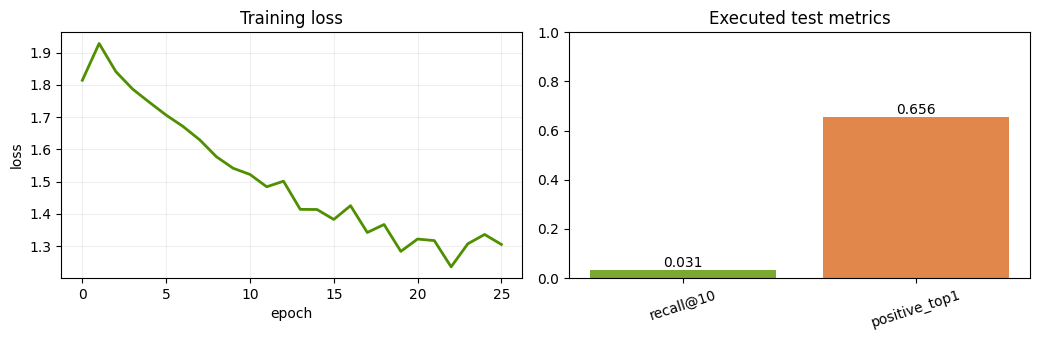

,value
recall@10,0.03125
positive_top1,0.65625


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'recall@10': result['recall@10'], 'positive_top1': result['positive_top1']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

## Test & Results Discussion

In [6]:
display(Markdown(f'''### 本次已执行结果

- 主指标 recall@10 = **{result['recall@10']:.4f}**。
- 辅助指标 positive_top1 = **{result['positive_top1']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实电影兴趣数不固定，胶囊可能重复或塌缩；小型 MovieLens 子集仍需同时看兴趣余弦、Coverage 与检索成本。

### 工业边界

user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 recall@10 = **0.0312**。
- 辅助指标 positive_top1 = **0.6562**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **1.8144** 降到 **1.3050**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 真实电影兴趣数不固定，胶囊可能重复或塌缩；小型 MovieLens 子集仍需同时看兴趣余弦、Coverage 与检索成本。

### 工业边界

user tower 输出 [B,K,d]；每个兴趣独立检索，再按最高分合并、去重和配额控制。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [7]:
record={
    'algorithm': 'MIND 多兴趣召回',
    'primary_metric': 'recall@10', 'primary_value': float(result['recall@10']),
    'secondary_metric': 'positive_top1', 'secondary_value': float(result['positive_top1']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '3_2_2_mind',
    'dataset': 'MovieLens latest-small',
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_3_2','3_2_2_mind',[record]); print('saved:',path.relative_to(ROOT))

saved: results/chapter_3_2/3_2_2_mind.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [8]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['recall@10']) <= 1
assert np.isfinite(float(result['positive_top1']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。